# How Quarterbacks Have Evolved: A Data Analysis of Nearly a Century of NFL Passing Statistics

**Author:** Evan Grebner
**Course:** DS 220 — Data Analysis Project
**Date:** May 2026

---

## 1. Problem Space

The scope of the NFL has changed drastically since its creation as a result of developments to the sport. I wanted to see if the numbers will support the visual differences you see when comparing two games from past and present.

**What:** How NFL Quarterback play has evolved from 1924 to 2016.

**Why:** To help fans and viewers get a better understanding of the impact quarterbacks have on the game and how that impact has continued to grow as the league progresses.

**Who:** Fans, journalists, and anyone curious about if quarterbacks are actually better today.

**When:** 1924 to 2016, 92 years of NFL football.

**Where:** Across all NFL franchises that have existed in the United States.

## 2. The Data

**NFL Statistics** by Kendall Gillies on Kaggle: https://www.kaggle.com/datasets/kendallgillies/nflstatistics

Two CSVs:

- **`Career_Stats_Passing.csv`** — 8,525 Quarterback seasons with pass yards, completion%, touchdowns, interceptions, sacks, and passer rating. Main file for analysis.
- **`Basic_Stats.csv`** — 17,172 player records with statistics(height/weight, college, birthplace). Used for the colleges question.

**Connection:** The `Year` column allows me to group by years to see how quarterback stats have changed over time.

## 3. Questions I Want to Explore:

1. **How has passing volume changed over the decades?**
2. **Have quarterbacks improved accuracy over time?**
3. **Which decades produced the best quarterbacks?**
4. **Which colleges have produced the most NFL quarterbacks?**
5. **Who are the top 10 quarterbacks by career passing yards?**
6. **How has the length of a quarterbacks career changed over time?**

## 4. Set Up: Loading the Data and Imports

In [43]:
# Import all libraries for the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# To display the plots in the notebook
%matplotlib inline

In [44]:
# Loading both csvs into Pandas DataFrames
passing = pd.read_csv("Career_Stats_Passing.csv")
basic = pd.read_csv("Basic_Stats.csv")

# Checking the size of both DataFrames
print("Passing data shape:", passing.shape)
print("Basic stats shape:", basic.shape)

Passing data shape: (8525, 23)
Basic stats shape: (17172, 16)


### First Look at the Data

In [45]:
# View the first 5 rows to understand the data
passing.head()

,Player Id,Name,Position,Year,Team,Games Played,Passes Attempted,Passes Completed,Completion Percentage,Pass Attempts Per Game,...,TD Passes,Percentage of TDs per Attempts,Ints,Int Rate,Longest Pass,Passes Longer than 20 Yards,Passes Longer than 40 Yards,Sacks,Sacked Yards Lost,Passer Rating
0,tomfarris/2513861,"Farris, Tom",NaN,1948,Chicago Rockets,0,--,--,--,0.0,...,--,--,--,--,--,--,--,--,--,0.0
1,tomfarris/2513861,"Farris, Tom",NaN,1947,Chicago Bears,9,2,0,0.0,0.2,...,0,0.0,0,0.0,--,0,0,0,0,39.6
2,tomfarris/2513861,"Farris, Tom",NaN,1946,Chicago Bears,11,21,8,38.1,1.9,...,1,4.8,2,9.5,--,0,0,0,0,31.5
3,billdemory/2512778,"Demory, Bill",NaN,1974,New York Jets,1,--,--,--,0.0,...,--,--,--,--,--,--,--,--,--,0.0
4,billdemory/2512778,"Demory, Bill",NaN,1973,New York Jets,6,39,12,30.8,6.5,...,2,5.1,8,20.5,--,0,0,8,73,22.2


In [46]:
# View column types and check missing values
passing.info()

<class 'pandas.DataFrame'>
RangeIndex: 8525 entries, 0 to 8524
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Player Id                       8525 non-null   str    
 1   Name                            8525 non-null   str    
 2   Position                        1111 non-null   str    
 3   Year                            8525 non-null   int64  
 4   Team                            8525 non-null   str    
 5   Games Played                    8525 non-null   int64  
 6   Passes Attempted                8525 non-null   str    
 7   Passes Completed                8525 non-null   str    
 8   Completion Percentage           8525 non-null   str    
 9   Pass Attempts Per Game          8525 non-null   float64
 10  Passing Yards                   8525 non-null   str    
 11  Passing Yards Per Attempt       8525 non-null   str    
 12  Passing Yards Per Game          8525 non-null

## 5. Data Cleaning

Many of the numeric columns show up as strings. Missing values are stored as "--" instead of `NaN`. `Passing Yards` uses numbers with commas. These issues need to be fixed before we can progress.

In [47]:
# 1. Fix the missing values  
passing = passing.replace("--", np.nan)

# 2. Remove commas from pass yards
passing["Passing Yards"] = passing["Passing Yards"].astype(str).str.replace(",", "")
passing["Passing Yards"] = passing["Passing Yards"].replace("nan", np.nan)

# 3. Convert numeric columns to hold numeric values
numeric_cols = [
    "Passes Attempted", "Passes Completed", "Completion Percentage",
    "Passing Yards", "Passing Yards Per Attempt", "Passing Yards Per Game",
    "TD Passes", "Percentage of TDs per Attempts", "Ints", "Int Rate",
    "Sacks", "Sacked Yards Lost"
]
for col in numeric_cols:
    passing[col] = pd.to_numeric(passing[col], errors="coerce")

# 4. Create decade column for grouping by decade
passing["Decade"] = (passing["Year"] // 10) * 10

In [48]:
# describe() displays summary stats for our numeric columns
passing.describe()

,Year,Games Played,Passes Attempted,Passes Completed,Completion Percentage,Pass Attempts Per Game,Passing Yards,Passing Yards Per Attempt,Passing Yards Per Game,TD Passes,Percentage of TDs per Attempts,Ints,Int Rate,Sacks,Sacked Yards Lost,Passer Rating,Decade
count,8525.000000,8525.000000,4347.000000,4347.000000,4239.000000,8525.000000,4347.000000,4239.000000,4337.000000,4347.000000,4239.000000,4347.000000,4239.000000,4347.000000,4347.000000,8525.000000,8525.000000
mean,1982.052551,10.294311,121.799172,68.794111,46.688818,5.787824,843.600644,6.663222,76.568388,5.303658,5.878226,4.989878,7.434820,7.735450,60.367380,32.226111,1977.590616
std,23.822176,5.305723,170.226894,102.194430,27.811635,10.533562,1228.021768,7.166957,88.260241,8.289670,15.904120,6.413098,16.452146,12.330431,89.283385,40.485956,24.059774
min,1924.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,-11.000000,-4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1920.000000
25%,1965.000000,6.000000,2.000000,1.000000,33.300000,0.000000,11.000000,3.500000,1.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1960.000000
50%,1985.000000,12.000000,26.000000,11.000000,50.800000,0.000000,150.000000,6.300000,31.000000,1.000000,2.600000,2.000000,3.100000,0.000000,8.000000,0.000000,1980.000000
75%,2003.000000,15.000000,201.000000,108.000000,60.000000,5.900000,1339.500000,7.500000,151.300000,8.000000,4.900000,9.000000,6.600000,12.000000,102.000000,64.900000,2000.000000
max,2016.000000,17.000000,727.000000,471.000000,100.000000,51.000000,5477.000000,81.000000,342.300000,55.000000,100.000000,35.000000,100.000000,76.000000,481.000000,158.300000,2010.000000


## 6. Exploratory Data Analysis

Before exploring my questions, let's look at how the data is distributed across the years.

In [49]:
# Count the number of quarterback season rows per decade
seasons_per_decade = passing["Decade"].value_counts().sort_index()
print(seasons_per_decade)

Decade
1920      40
1930     494
1940     582
1950     529
1960     941
1970    1028
1980    1136
1990    1214
2000    1416
2010    1145
Name: count, dtype: int64


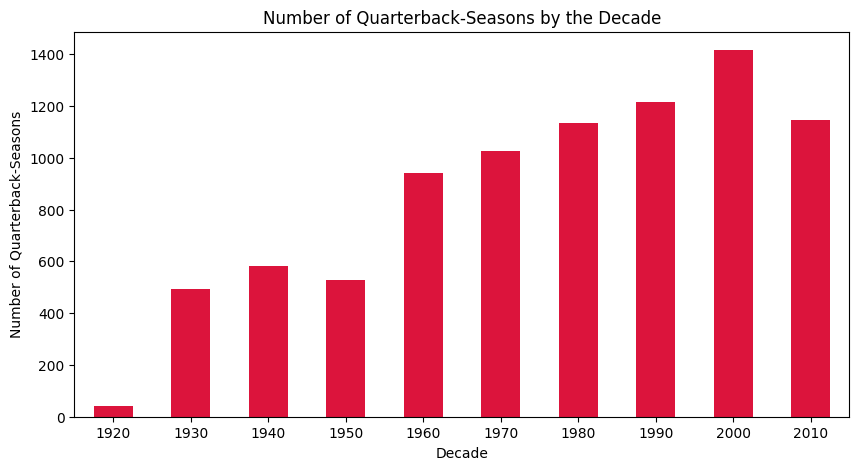

In [50]:
# Create a bar chart to visualize
plt.figure(figsize=(10, 5))
seasons_per_decade.plot(kind="bar", color="crimson")
plt.title("Number of Quarterback-Seasons by the Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Quarterback-Seasons")
plt.xticks(rotation=0)
plt.show()

**Observation:** The 1920s only have 40 records because the league was much smaller. Earlier decades may be unreliable due to the league having fewer teams. Only quarterbacks with at least 75 attemps will be included.


In [51]:
# Filter the data to include only impactful seasons(75 attempt minimum)
ATTEMPT_THRESHOLD = 75
qb_seasons = passing[passing["Passes Attempted"] > ATTEMPT_THRESHOLD]
print(f"Filtered to {len(qb_seasons)} quarterback  seasons with over {ATTEMPT_THRESHOLD} pass attempts.")

Filtered to 1653 quarterback  seasons with over 75 pass attempts.


## 7. Question 1: How has passing volume changed over the decades?

To explore this, I'll plot the league-wide average passing yards/game by year.

In [52]:
# First group by year and then take the mean of pass yds/game for each quarterback in that year
avgyards_by_year = qb_seasons.groupby("Year")["Passing Yards Per Game"].mean()


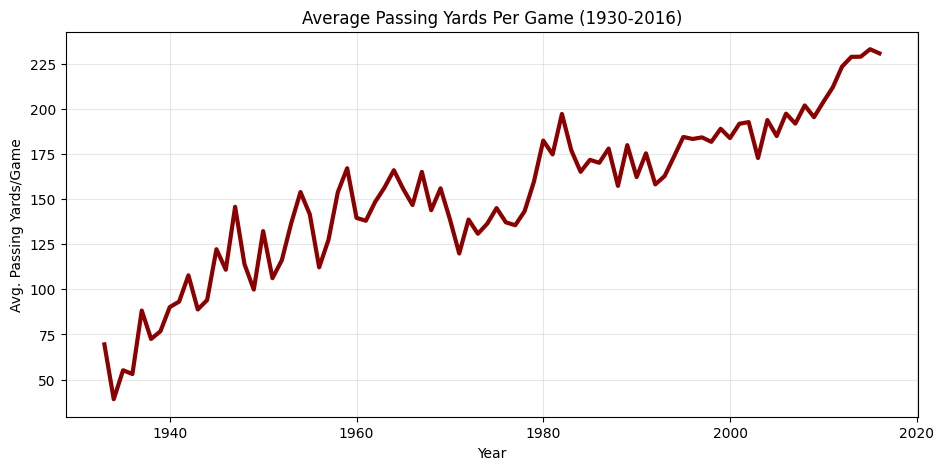

In [53]:
# Plot the data as a line graph 
plt.figure(figsize=(11, 5))
avgyards_by_year.plot(color="darkred", linewidth=3)
plt.title("Average Passing Yards Per Game (1930-2016)")
plt.xlabel("Year")
plt.ylabel("Avg. Passing Yards/Game")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:** The trend is very noticeable. Average passing yards per game has consistently grown over the years and has tripled since the 40s. The current Day NFL sees significantly more passing volume than previous eras due to rule changes and offensive innovations like the West Coast offense.

## 8. Question 2: Have quarterbacks gotten more accurate over time?

I'll analyze completion percentage by the decade.

In [54]:
# Group seasons by the decade and take the mean of completion percentage for era by era comparison
comp_pct_by_decade = qb_seasons.groupby("Decade")["Completion Percentage"].mean()
print(comp_pct_by_decade.round(2))

Decade
1930    44.87
1940    47.60
1950    49.33
1960    49.51
1970    51.88
1980    54.88
1990    56.90
2000    59.47
2010    61.11
Name: Completion Percentage, dtype: float64


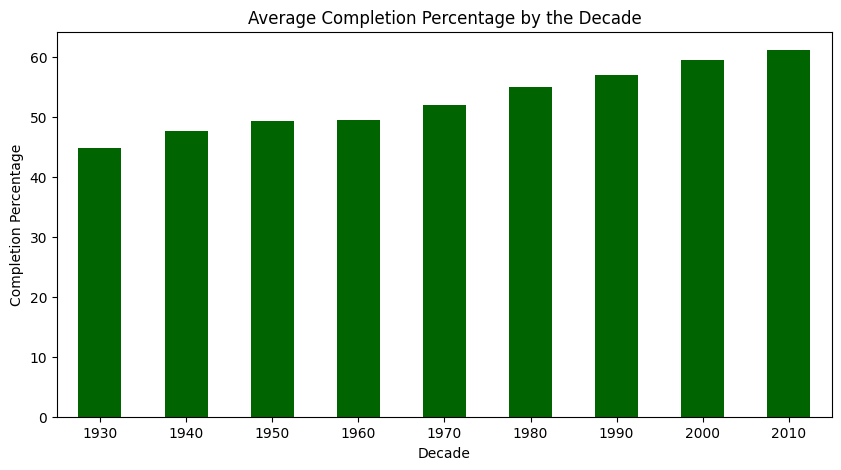

In [55]:
# Create a bar chart to show the comp % stats by decade
plt.figure(figsize=(10, 5))
comp_pct_by_decade.plot(kind="bar", color="darkgreen")
plt.title("Average Completion Percentage by the Decade")
plt.xlabel("Decade")
plt.ylabel("Completion Percentage")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Completion percentage rose steadily from the 1930s to the 2010s. Quarterbacks have been slowly becoming more efficient over the decades. Better coaching and offensive innovation have led to much improved passing concepts which help to explain this trend.

## 9. Question 3: Which decades produced the best quarterbacks?

To answer this, I will look at Passer Rating, which combines several important statistics to evaluate a quarterbacks overall performance.

In [56]:
# Group by decade and take theaverage the Passer Rating
rating_by_decade = qb_seasons.groupby("Decade")["Passer Rating"].mean()
print(rating_by_decade.round(2))

Decade
1930    48.48
1940    58.02
1950    60.88
1960    65.61
1970    63.79
1980    72.37
1990    76.20
2000    78.88
2010    85.02
Name: Passer Rating, dtype: float64


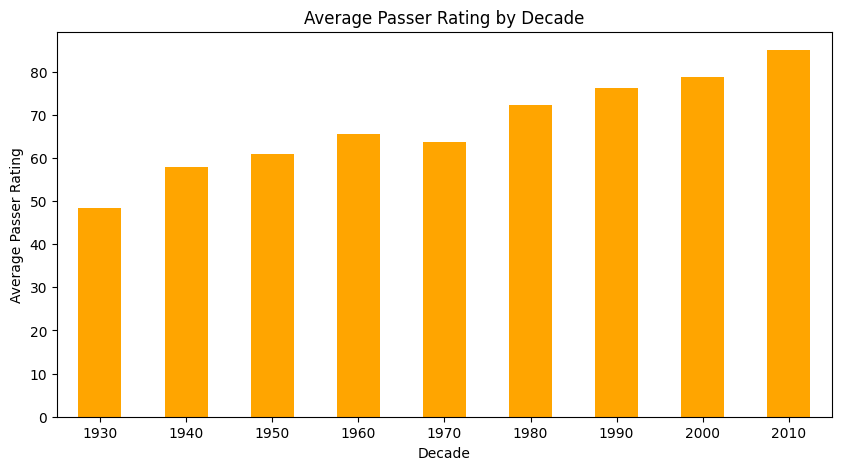

In [57]:
# Create a bar chart showing the average Passer Rating for each decade
plt.figure(figsize=(10, 5))
rating_by_decade.plot(kind="bar", color="orange")
plt.title("Average Passer Rating by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Passer Rating")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** It is clear from this chart that modern era quarterbacks have played better than the rest of the eras. Passer rating has nearly doubled since the 1930s and has consistently increased in all but one decade. This shows more evidence that passing in the NFL has become much more prevalent and effective.

## 10. Question 4: What colleges produce the most NFL quarterbacks?

I'll join the passing data with the basic stats to pull each players college.

In [58]:
# Gather a list of each unique player in the passing data using their player id
qb_ids = passing["Player Id"].unique()

# Select only those players from the basic stats data
qb_basic = basic[basic["Player Id"].isin(qb_ids)]

# Gather counts of each quarterback's attended college
top_colleges = qb_basic["College"].value_counts().head(10)
print(top_colleges)

College
USC             35
Notre Dame      31
LSU             27
UCLA            22
Michigan        21
Miami (Fla.)    21
Georgia         20
Ohio State      20
Tennessee       20
Pittsburgh      19
Name: count, dtype: int64


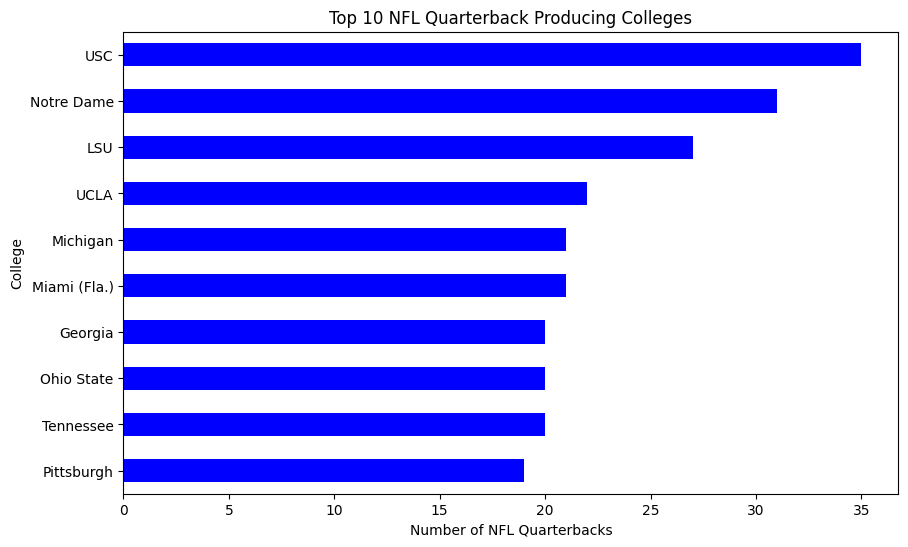

In [59]:
# Create a horizontal bar chart to display the top 10 colleges 
plt.figure(figsize=(10, 6))
top_colleges.plot(kind="barh", color="blue")
plt.title("Top 10 NFL Quarterback Producing Colleges")
plt.xlabel("Number of NFL Quarterbacks")
plt.ylabel("College")
plt.gca().invert_yaxis()  # Put the school with the mostat the top
plt.show()

**Interpretation:** USC takes the lead with 35 NFL QBs, followed by Notre Dame and LSU. There is a clear dropoff after the top 3, with many schools around the 20 mark. All Colleges shown have been long term football powerhouses, no surprises here.

## 11. Question 5: Who are the quarterbacks with the most career passing yards?

Sum each quarterbacks yards for every season played to get total career yardage.

In [60]:
# Group by player Name and sum their passing yards across each season they played
career_yards = (passing.groupby("Name")["Passing Yards"]
                .sum()
                .sort_values(ascending=False) # Descending order
                .head(10)) # Get only the top 10
print(career_yards)

Name
Manning, Peyton        71940.0
Favre, Brett           71838.0
Brees, Drew            66111.0
Brady, Tom             61582.0
Marino, Dan            61361.0
Elway, John            51475.0
Manning, Eli           48214.0
Tarkenton, Fran        47003.0
Roethlisberger, Ben    46814.0
Testaverde, Vinny      46233.0
Name: Passing Yards, dtype: float64


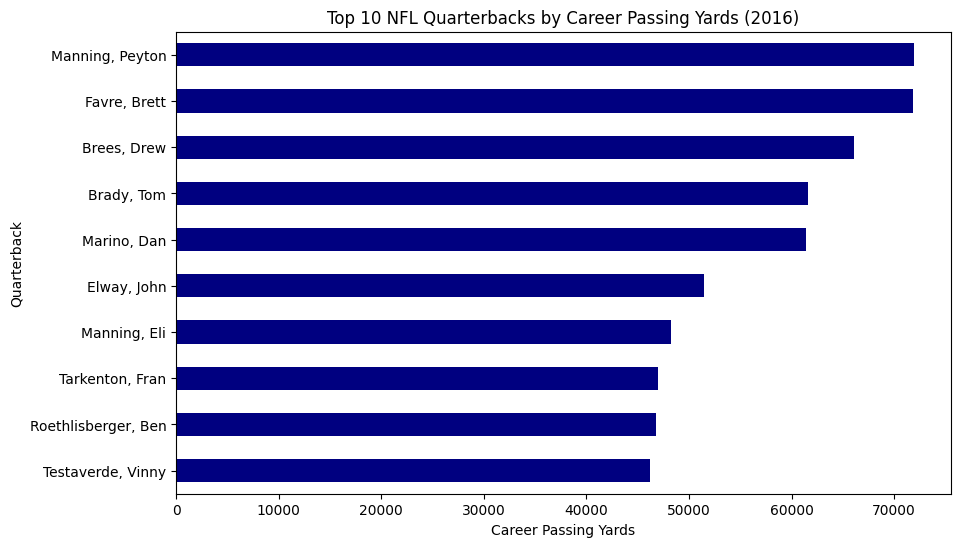

In [61]:
# Create a horizontal bar chart showing the all-time passing leaders
plt.figure(figsize=(10, 6))
career_yards.plot(kind="barh", color="navy")
plt.title("Top 10 NFL Quarterbacks by Career Passing Yards (2016)")
plt.xlabel("Career Passing Yards")
plt.ylabel("Quarterback")
plt.gca().invert_yaxis()
plt.show()

**Interpretation:** Peyton Manning has the most career passing yards in the NFL with almost 72,000. The rest of the top 5 includes Favre, Brees, Brady, and Marino. This chart also supports the trends discovered earlier, with a majority of this list playing in recent eras. Today's quarterbacks throw more frequently and efficiently, leading them to gain yards faster.

## 12. Question 6: How has the length of a quarterbacks career changed over time?

I'll get each players career length, then compare each decades average quarterback career length.

In [62]:
# Calculate each players first and last season played
career_lengths = qb_seasons.groupby("Player Id").agg(
    debut_year=("Year", "min"),
    last_year=("Year", "max"),
)
# subtract each players first year by their final season to get career length
career_lengths["career_length"] = career_lengths["last_year"] - career_lengths["debut_year"] + 1

# Sort each player into the decade they played their first season
career_lengths["debut_decade"] = (career_lengths["debut_year"] // 10) * 10

# Exclude the 2010s because this will include active players data whos careers are ongoing.
updated_data = career_lengths[career_lengths["debut_decade"] < 2010]

# Group by the decade and take the average career length per decade
avg_career = updated_data.groupby("debut_decade")["career_length"].mean()
print(avg_career.round(2))

debut_decade
1930    3.60
1940    3.63
1950    5.76
1960    6.38
1970    6.62
1980    7.73
1990    5.86
2000    6.73
Name: career_length, dtype: float64


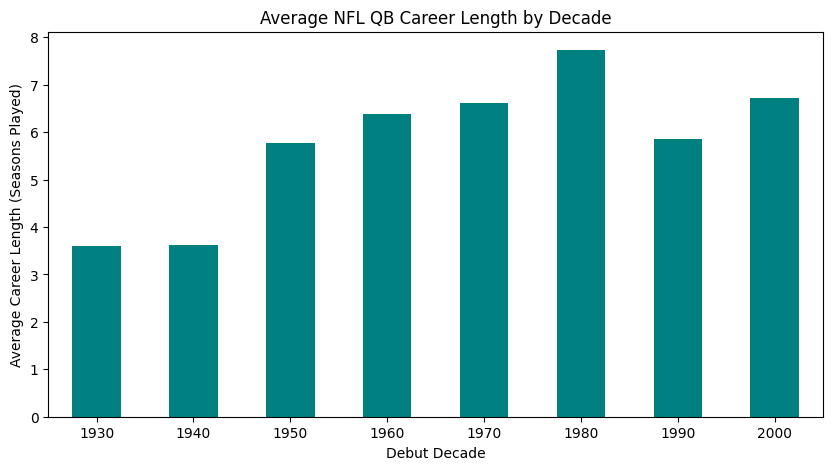

In [63]:
# create a bar chart showing average career length for each decade
plt.figure(figsize=(10, 5))
avg_career.plot(kind="bar", color="teal")
plt.title("Average NFL QB Career Length by Decade")
plt.xlabel("Debut Decade")
plt.ylabel("Average Career Length (Seasons Played)")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The average length of a quarterbacks career has almost doubled since the 1940s going from an average of 3.6 years up to 6.7 in the 2000s. After the significant growth from the 40s to 50s, the trend has been less predictable with a dip in the 90s and less rapid growth. This could be a result of early rule changes prioritizing player health. *(The 2010s were excluded because many players careers are unfinished)*

## 13. Insights: The Evolution of Quarterbacks

Looking at all the plots together, you can clearly see that the NFL has transformed from a run heavy league into a passing league. What is expected of a quarterback has changed dramatically over the course of the league. Three of the questions resulted in insights that support each other: passing volume, accuracy, and overall efficiency(Pass Rating) have all consistently grown as years go by. Those three observations provide an explanation for why the all time career passing yards list contains primarily recent players. Quarterbacks in todays league throw the ball more, throw more accurate balls, and play more total seasons. Quarterbacks have evolved and become the most important position on the field.

**Why this matters:** Fans can get some insight on why a lot of passing records are being broken. This also puts real numbers behind the discussion about the NFLs transition into a pass dominant league.

**Limitations:** The data ends in 2016, this greatly affects the top 10 list and excludes some record breaking seasons that could show even more development of the position. Grouping by decade can hide some of the true variation and trends.